# Stage 4B — Asynchronous FeatureState update

This experiment uses the Stage 4A brute-force spatial/temporal gates online: events are stably ordered by timestamp, each is associated against the current FeatureState memory, and a selected state is updated immediately before processing the next event. Position uses the alpha correction and velocity uses beta times residual divided by elapsed microseconds. At `Δt=0`, position updates but velocity is held; positive small `Δt` uses `max(Δt, minimum_delta_t_us)`. Confidence is reduced by a configurable penalty proportional to the normalized squared association residual. Invalid state slots are excluded and never activated. Unrepresentable updates are rejected atomically. No grid hashing, Kalman filter, or patches are used.

In [3]:
import importlib
import sys
from pathlib import Path

project_root = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / "src" / "event_state_update.py").is_file()),
    None,
)
if project_root is None:
    raise FileNotFoundError("Could not locate the project root")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.davis_inspection import DavisConfig, load_davis
import src.frame_synchronization as frame_synchronization
frame_synchronization = importlib.reload(frame_synchronization)
import src.event_state_update as event_state_update
event_state_update = importlib.reload(event_state_update)
from src.aps_features import ShiTomasiConfig, extract_shi_tomasi_features
from src.feature_state_memory import initialize_from_aps_features

dataset_config = DavisConfig()
recording = load_davis(dataset_config)
origins_s, _ = frame_synchronization.load_timestamp_origins(recording, dataset_config)
windows = frame_synchronization.make_frame_windows(recording, origins_s)
interval_index = min(678, len(windows) - 1)
window = windows.get_window(interval_index)
configuration = {
    "radius_px": 8.0,
    "time_window_us": 50_000.0,
    "alpha": 0.5,
    "beta": 0.1,
    "minimum_delta_t_us": 1.0,
    "confidence_penalty": 0.05,
}
features = extract_shi_tomasi_features(
    window.frame_k,
    ShiTomasiConfig(max_features=500),
    frame_index=interval_index,
    frame_timestamp_us=window.frame_k_common_time_us,
).features
memory = initialize_from_aps_features(
    features, window.frame_k_common_time_us, slot_count=500
)
initial_states = memory.storage.copy()
evolution, events_per_feature, diagnostics = event_state_update.run_asynchronous_updates(
    window.events_k,
    memory,
    configuration["radius_px"],
    configuration["time_window_us"],
    alpha=configuration["alpha"],
    beta=configuration["beta"],
    minimum_delta_t_us=configuration["minimum_delta_t_us"],
    confidence_penalty=configuration["confidence_penalty"],
    event_timestamp_offset_us=window.event_timestamp_offset_us,
)
outputs = event_state_update.save_update_outputs(
    window.frame_k,
    window.frame_k_plus_1,
    initial_states,
    memory.storage,
    evolution,
    events_per_feature,
    diagnostics,
    window,
    configuration,
    event_state_update.DEFAULT_OUTPUT_DIR,
)
dict(diagnostics), outputs

({'events_processed': 10879,
  'successful_updates': 1555,
  'events_rejected': 9324,
  'events_ambiguous': 576,
  'association_ratio': 0.14293593161136134,
  'active_features_initial': 500,
  'active_features_final': 500,
  'features_with_updates': 132,
  'mean_events_per_updated_feature': 11.780303030303031,
  'max_events_per_feature': 44,
  'mean_position_update_magnitude': 2.0297855867984143,
  'max_position_update_magnitude': 3.994744274315267,
  'mean_velocity_update_magnitude': 0.011447682836172555,
  'max_velocity_update_magnitude': 0.5458268078536216},
 {'evolution': PosixPath('/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/event_state_update/davis_feature_state_evolution.npz'),
  'diagnostics': PosixPath('/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/step_1_VIO/results/event_state_update/davis_feature_state_update_diagnostics.json'),
  'csv': PosixPath('/home/administrator/Desktop/MVBC/Research_Work/06_Experiments/SNN/

# Stage 4B — Asynchronous FeatureState update

- APS interval: 678, [29895515, 29939581) μs
- Events processed: 10879
- Successful updates: 1555
- Rejected events: 9324
- Ambiguous events: 576
- Initial active features: 500
- Final active features: 500
- Features with at least one update: 132
- Mean / maximum events per updated feature: 11.780 / 44
- Mean position update magnitude: 2.02979 px
- Maximum position update magnitude: 3.99474 px
- Mean velocity update magnitude: 0.0114477 px/μs
- Maximum velocity update magnitude: 0.545827 px/μs
- Alpha / beta: 0.5 / 0.1
- Confidence penalty: 0.05
- Zero Δt: position correction is applied; velocity is unchanged.
- Positive small Δt: velocity denominator is clamped to the configured minimum.
- Only valid states are considered; invalid slots remain unchanged.
- Numerically unrepresentable updates are rejected atomically.
- Feature states contain no image patches; no Kalman filter is used.

Event pixels, pre-update predictions, and post-update positions are separately marked in the trajectory visualization.


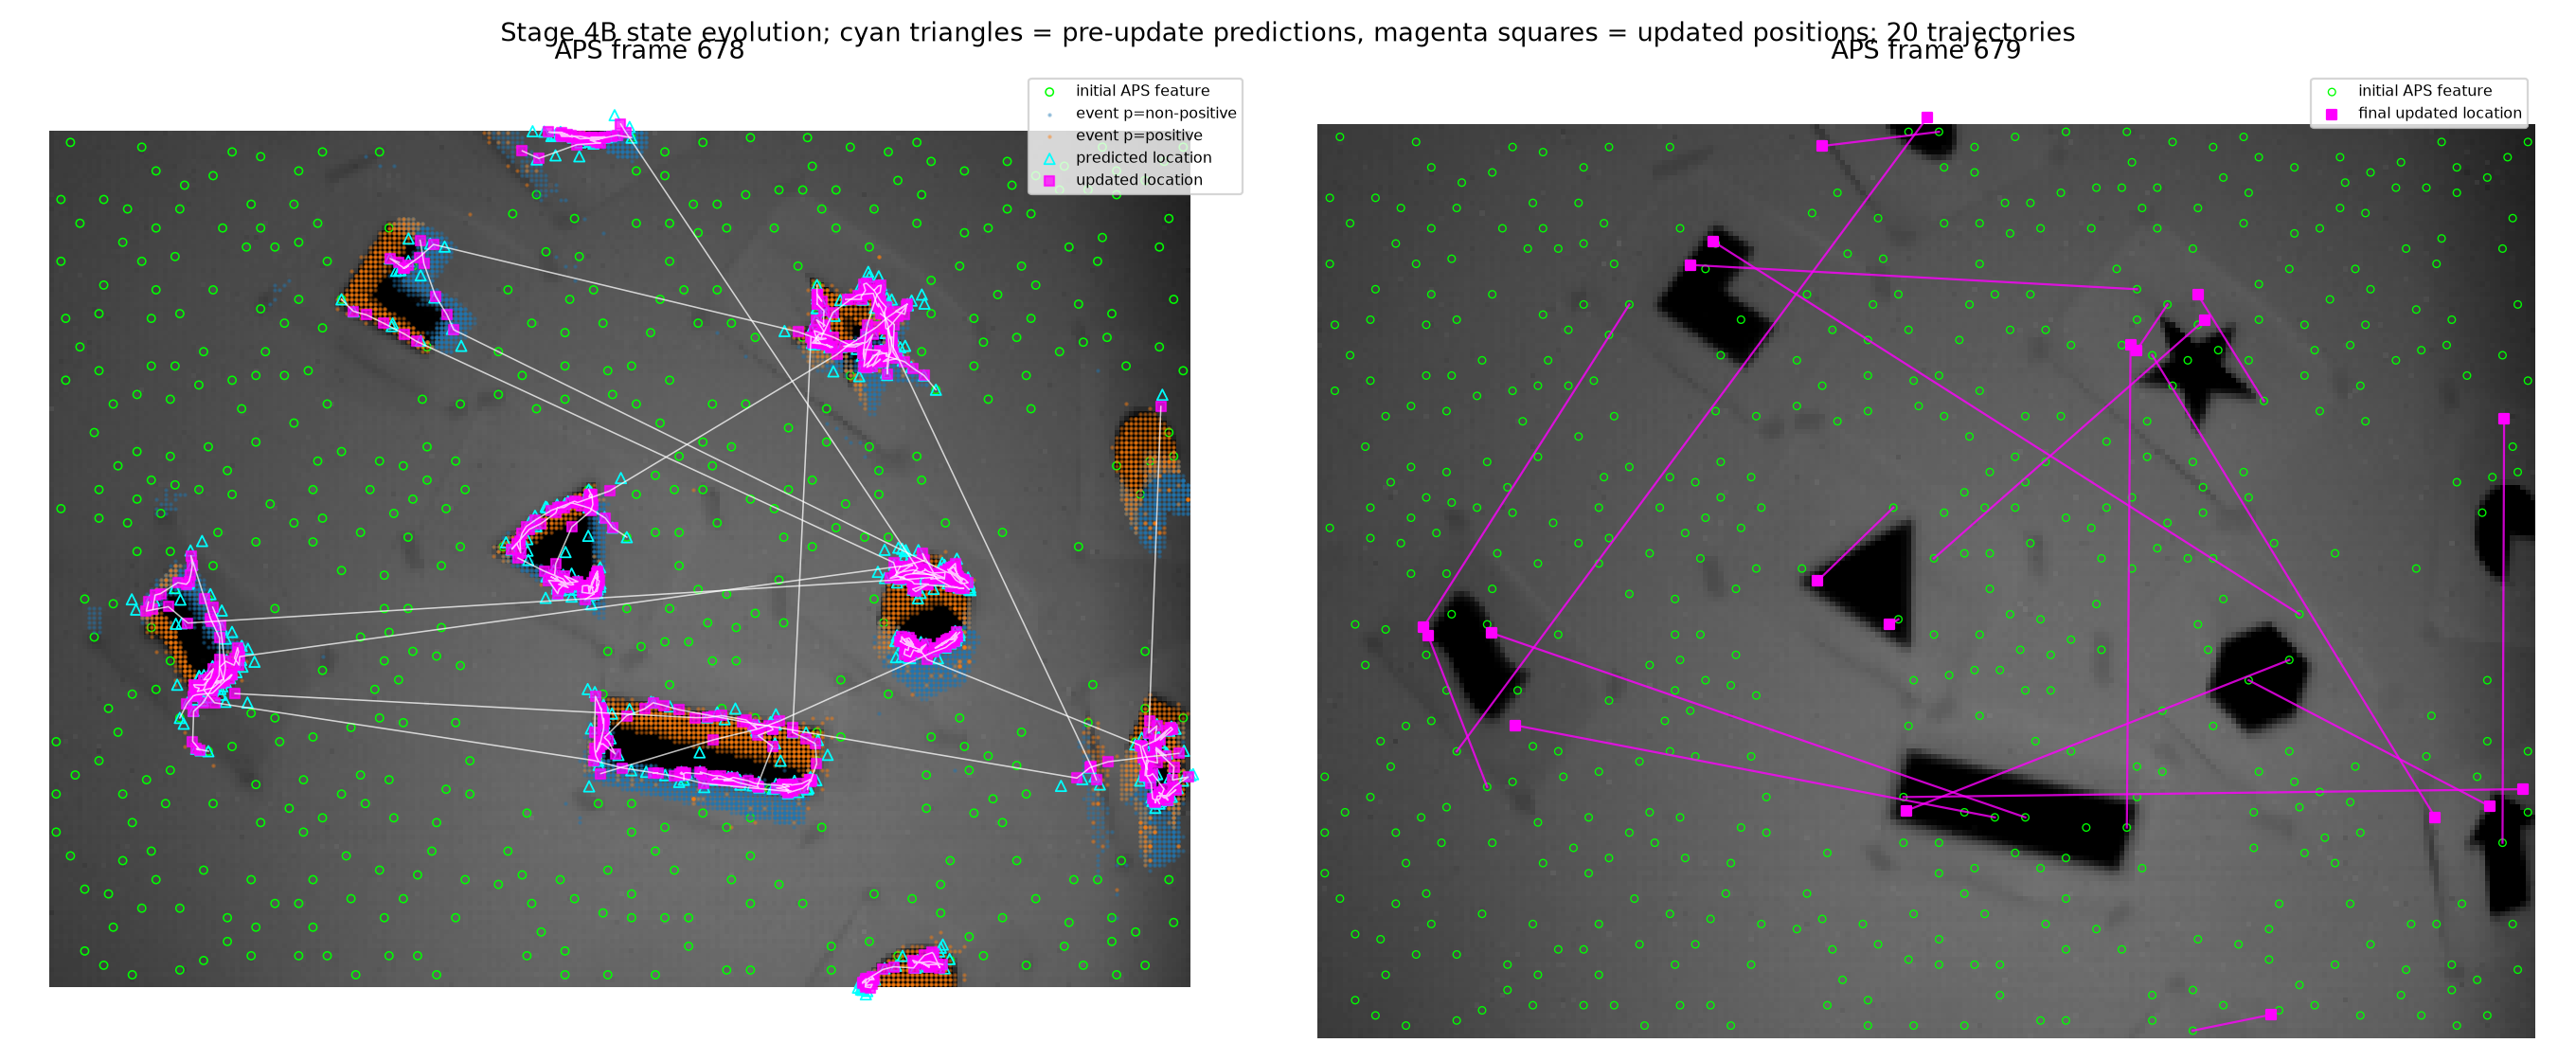

In [4]:
from IPython.display import Image, Markdown, display

display(Markdown(outputs["report"].read_text()))
display(Image(filename=str(outputs["visualization"])))